# 01 — Spectrogram & Window Sizing

**Discharge 1, Detector 1.**

This notebook establishes the baseline for the analysis:
1. Validating that DMD eigenvalues are converted to physical frequencies ($f$) and growth rates ($\gamma$) correctly.
2. Generating the reference STFT spectrogram and extracting the coherent frequency ridge ($f_{STFT}(t)$).
3. Scanning the BOP-DMD window length to demonstrate why $\gamma(t)$ collapses at longer windows, motivating our use of a short 0.5 ms window.

In [1]:
# Imports

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import pandas as pd
from pydmd import BOPDMD, DMD

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

from src import config
from src.math_helpers import (
    load_data, get_reference_spectrogram, fetch_window, local_fourier_seed,
    rank_selection, fit_bopdmd, eig_to_f_gamma_continuous, eig_to_f_gamma_discrete,
    energy_fraction
)

In [2]:
# Load the data
ctx = load_data()

## 1. Eigenvalue-Unit Sanity Check

`pydmd.BOPDMD` returns continuous-time eigenvalues (rad/s) directly. Exact `DMD` returns discrete-time eigenvalues and requires a conversion via `ln(lambda)/dt`.

To prove the conversion works, we generate a synthetic wave with a known frequency (220 kHz) and growth rate ($\gamma = -500 \text{ s}^{-1}$), and test both algorithms.

In [3]:
# Generate a synthetic multi-channel wave
n_ch, n_t, fs_synth = 8, 1000, 2e6
t_synth = np.arange(n_t) / fs_synth
phase = np.linspace(0, np.pi, n_ch)

# Known parameters: f = 220 kHz, gamma = -500 /s
true_sig = np.exp((-500.0 + 2j * np.pi * 220e3) * t_synth)
X_synth = np.outer(np.exp(1j * phase), true_sig).real + 0.05 * np.random.randn(n_ch, n_t) # add Gaussian noise

print("Truth: f = 220.000 kHz, gamma = -500.0 /s\n" + "-"*45)

# 1. BOP-DMD (Continuous)
bop = BOPDMD(svd_rank=2, num_trials=0, use_proj=False, eig_constraints={'limited'}, real_eig_limit=1e6)
bop.fit(X_synth, t_synth)
f_b, g_b = eig_to_f_gamma_continuous(bop.eigs)
print(f"BOP-DMD   -> f={f_b[0]/1e3:.3f} kHz, gamma={g_b[0]:.1f} /s (Continuous)")

# 2. Exact DMD (Discrete)
dmd = DMD(svd_rank=2)
dmd.fit(X_synth)
f_d, g_d = eig_to_f_gamma_discrete(dmd.eigs, dt=1/fs_synth)
print(f"Exact DMD -> f={f_d[0]/1e3:.3f} kHz, gamma={g_d[0]:.1f} /s (Discrete, note damping bias)")

Truth: f = 220.000 kHz, gamma = -500.0 /s
---------------------------------------------
BOP-DMD   -> f=219.999 kHz, gamma=-493.8 /s (Continuous)
Exact DMD -> f=219.999 kHz, gamma=-3766.5 /s (Discrete, note damping bias)


## 2. Reference Spectrogram & Ridge Tracking

A Viterbi tracker pulls the dominant frequency ridge ($f_{STFT}(t)$) which acts as the validation anchor for the rest of the analysis.

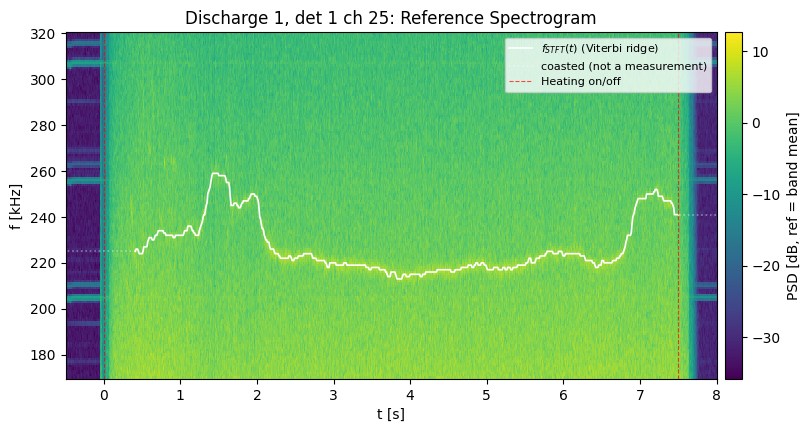

In [4]:
# Compute the Viterbi ridge
ref = get_reference_spectrogram(ctx)

fig, ax = plt.subplots(figsize=(10, 4.5))
Sxx_disp_db = 10 * np.log10(ref['Sxx'][ref['disp_a']] / np.mean(ref['Sxx'][ref['disp_a']]))

im = ax.pcolormesh(ref['t'], ref['f'][ref['disp_a']] / 1e3, Sxx_disp_db, shading='auto',
                   cmap='viridis', vmin=np.percentile(ref['Sxx_db'], 10),
                   vmax=np.percentile(ref['Sxx_db'], 99.9))

# Plot the tracked Viterbi Ridge
ax.plot(ref['t'], ref['ridge_f'] / 1e3, color='w', lw=1.2, label=r'$f_{STFT}(t)$ (Viterbi ridge)')
ax.plot(ref['t'][ref['early_excl']], ref['ridge_f_smooth'][ref['early_excl']] / 1e3,
        color='w', lw=1.2, ls=':', alpha=0.4, label='coasted (not a measurement)')
ax.plot(ref['t'][ref['late_excl']], ref['ridge_f_smooth'][ref['late_excl']] / 1e3,
        color='w', lw=1.2, ls=':', alpha=0.4)

ax.axvline(ctx['t_on'], color='r', ls='--', lw=0.8, alpha=0.7, label='Heating on/off')
ax.axvline(ctx['t_off'], color='r', ls='--', lw=0.8, alpha=0.7)

ax.set_xlim(ctx['t_on'] - 0.5, ctx['t_off'] + 0.5)
ax.set_title(f"Discharge 1, det {config.DET} ch {config.CH_REF}: Reference Spectrogram")
ax.set_ylabel('f [kHz]')
ax.set_xlabel('t [s]')
ax.legend(loc='upper right', fontsize=8)
fig.colorbar(im, ax=ax, label='PSD [dB, ref = band mean]', pad=0.01)

plt.show()

## 3. Window-Length Sensitivity Scan

The growth-rates appear to converge toward zero for wider time windows using a single exponential, but it seems that it is not a physical result, since the underlying `energy_frac` also drops off. Seems that longer windows averages away the real mode's coherence, so the algorithm instead reports the eval of a negligible energy pole that happens to sit near the zero-growth seed.

Note that the run time for the pre-selected time windows is ~55mins.

In [5]:
test_times = [1.3, 2.3, 4.0, 5.5, 7.0]
win_lengths = config.WIN_SENSITIVITY  

sensitivity_results = []

for tc in test_times:
    seed_stft = float(np.interp(tc, ref['ridge_t_valid'], ref['ridge_f_valid']))
    
    for win in win_lengths:
        try:
            # Fetch data around this time center
            X, t_local = fetch_window(ctx['d'], tc, win, ctx['fs'])
            
            # Refine the STFT seed using a quick periodogram on this local window
            local_seed = local_fourier_seed(X, ctx['fs'], seed_stft)
            
            # Fit BOP-DMD
            rank, _ = rank_selection(X)
            m = fit_bopdmd(X, t_local, rank, local_seed)
            f_all, g_all = eig_to_f_gamma_continuous(m.eigs)
            efrac = energy_fraction(np.asarray(m.amplitudes))
            
            # Select the highest energy pole inside the allowed band
            cand_mask = np.where((f_all > 0) & (np.abs(f_all - seed_stft) <= config.MODE_BAND_MARGIN))[0]
            if cand_mask.size == 0:
                continue
                
            best_idx = cand_mask[np.argmax(efrac[cand_mask])]
            
            # Store the result
            sensitivity_results.append({
                't': tc, 'win': win, 
                'f': f_all[best_idx], 'gamma': g_all[best_idx], 'efrac': efrac[best_idx]
            })
            
        except Exception as e:
            print(f"Failed at t={tc}s, win={win*1e3}ms: {e}")

# Convert results to a structured array for plotting
df_sens = pd.DataFrame(sensitivity_results)

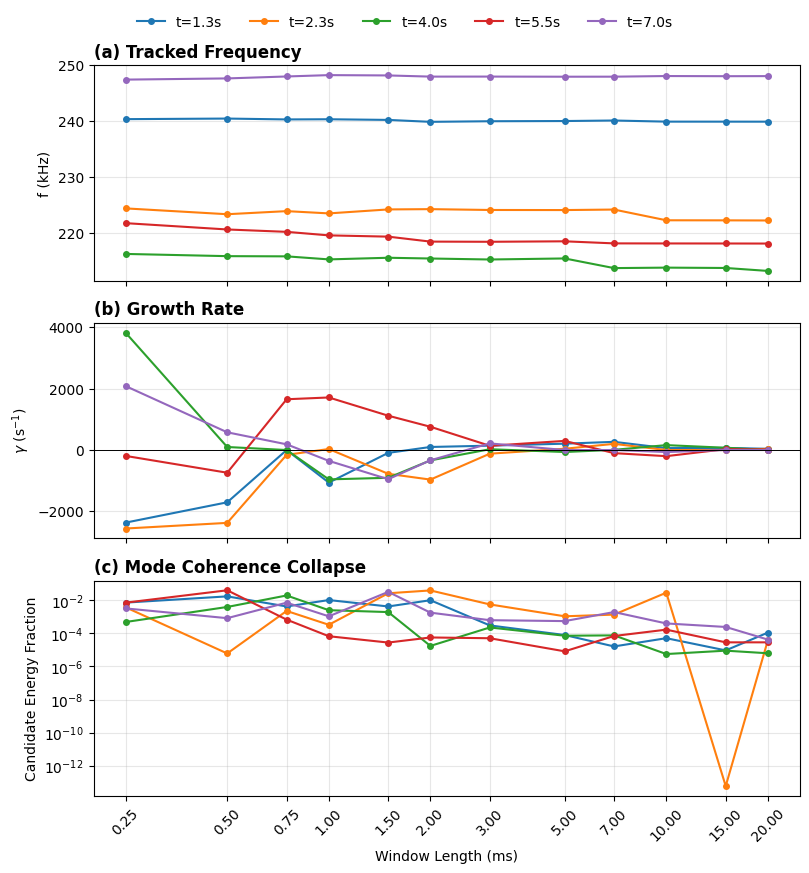

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(8.2, 8.5), sharex=True)
cmap = plt.get_cmap('tab10')

for i, tc in enumerate(test_times):
    sub = df_sens[df_sens['t'] == tc].sort_values('win')
    if sub.empty: continue
        
    color = cmap(i % 10)
    wl_ms = sub['win'] * 1e3
    
    ax[0].plot(wl_ms, sub['f'] / 1e3, 'o-', color=color, label=f't={tc:.1f}s', markersize=4)
    ax[1].plot(wl_ms, sub['gamma'], 'o-', color=color, markersize=4)
    ax[2].plot(wl_ms, sub['efrac'], 'o-', color=color, markersize=4)

ax[0].set_ylabel('f (kHz)')
ax[0].set_title('(a) Tracked Frequency', loc='left', fontweight='bold')

ax[1].axhline(0, color='k', lw=0.7)
ax[1].set_ylabel(r'$\gamma$ (s$^{-1}$)')
ax[1].set_title('(b) Growth Rate', loc='left', fontweight='bold')

ax[2].set_yscale('log')
ax[2].set_ylabel('Candidate Energy Fraction')
ax[2].set_xlabel('Window Length (ms)')
ax[2].set_title('(c) Mode Coherence Collapse', loc='left', fontweight='bold')

win_ticks = sorted(df_sens['win'].unique() * 1e3)

for a in ax:
    a.set_xscale('log')
    a.grid(alpha=0.3)
    a.set_xticks(win_ticks)
    a.xaxis.set_major_formatter(mticker.ScalarFormatter())
    a.xaxis.set_minor_locator(mticker.NullLocator())

ax[2].tick_params(axis='x', labelrotation=45)
fig.legend(*ax[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=5, frameon=False)
fig.tight_layout()
plt.show()